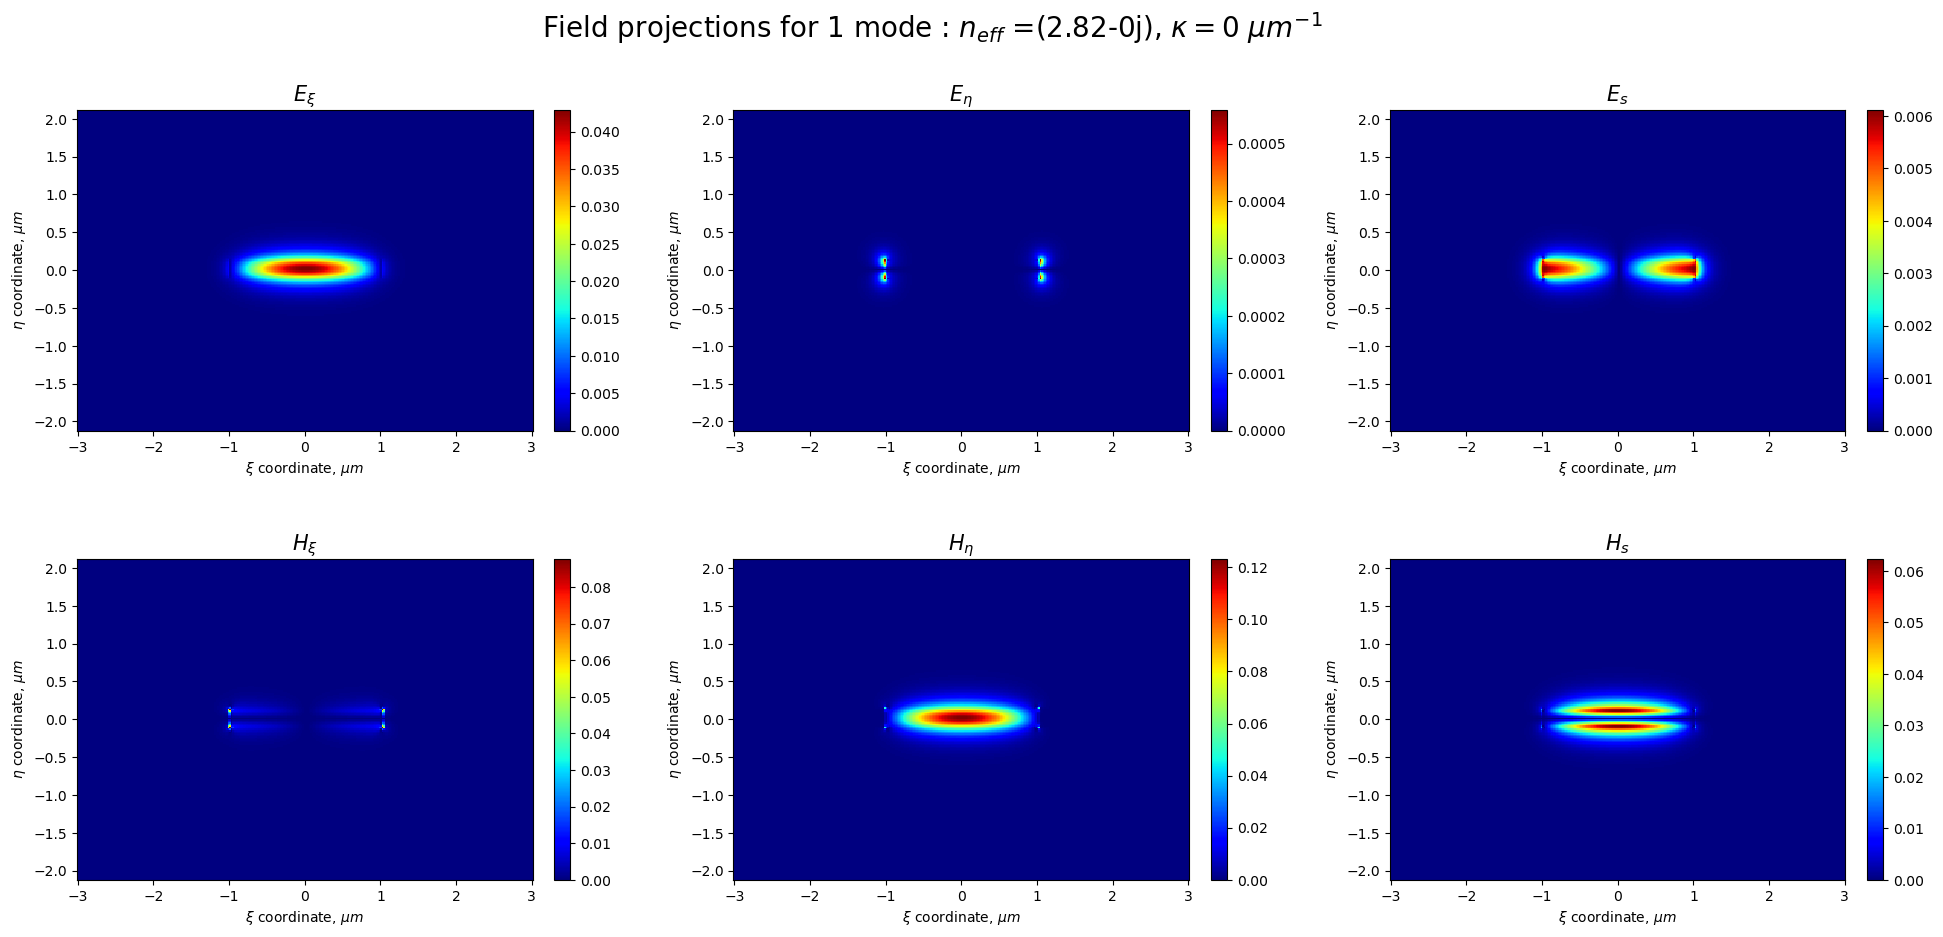

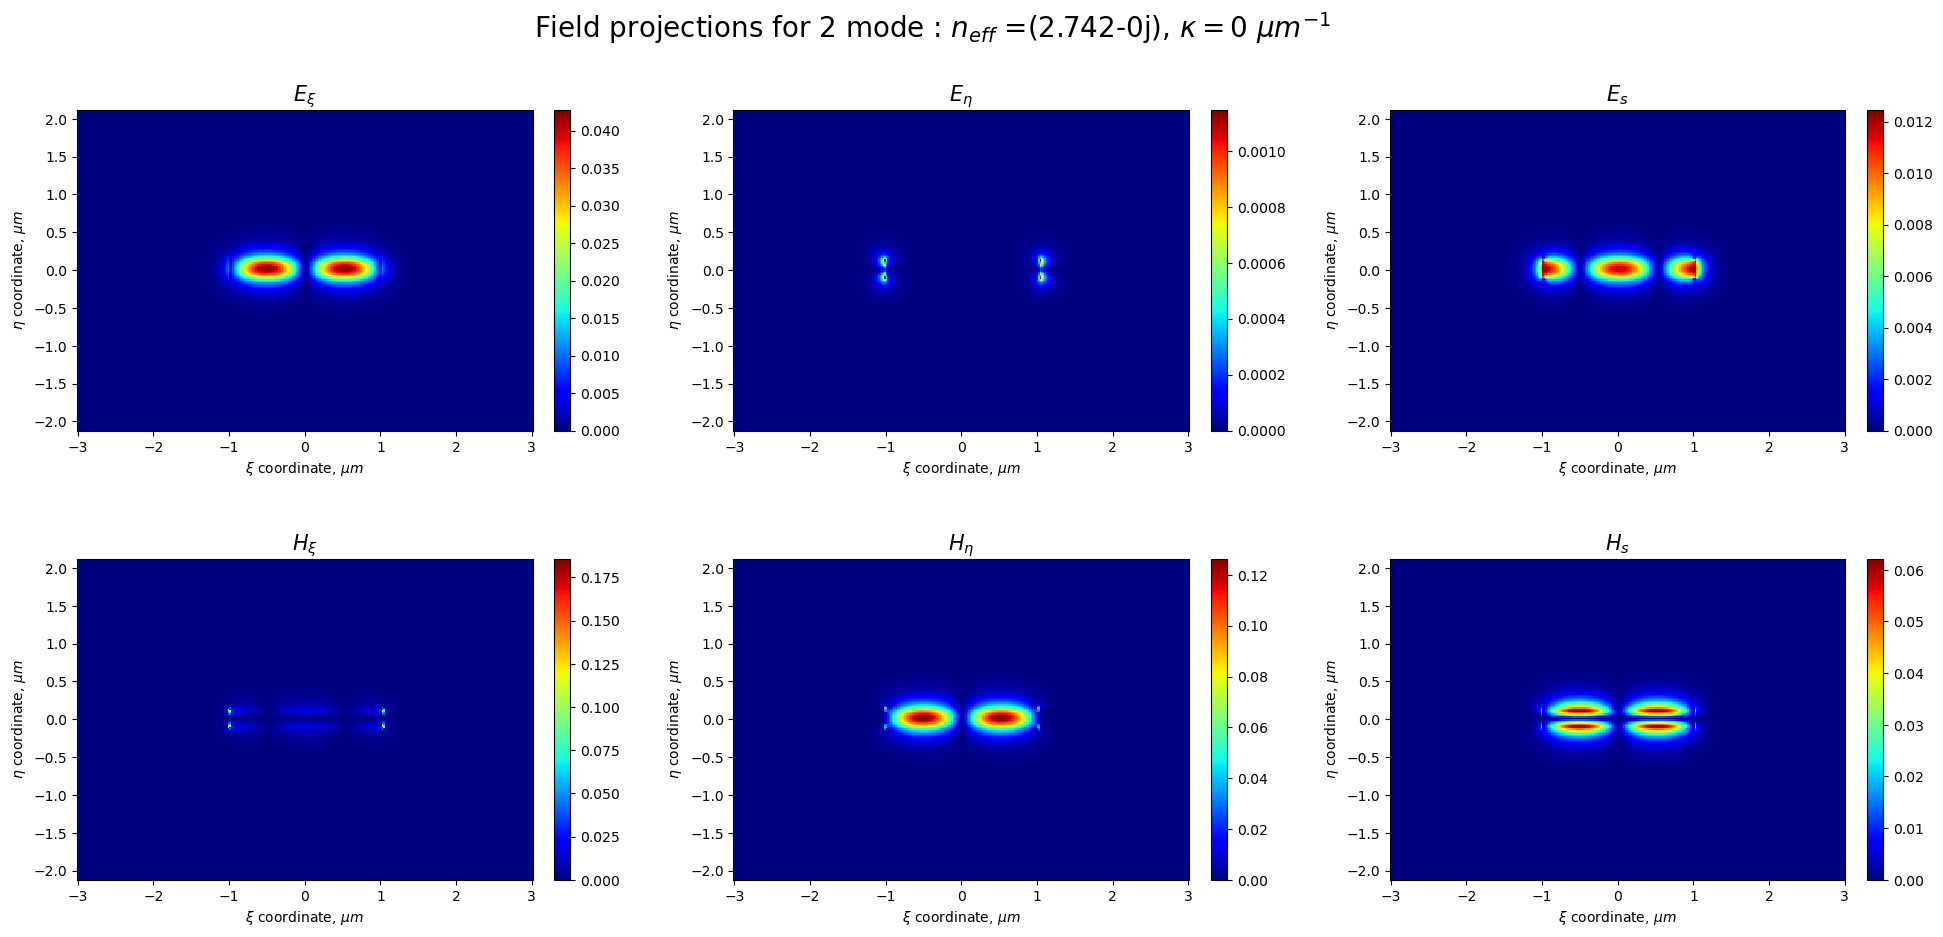

In [2]:
import curved_modesolver as cms

keke = cms.rect_WG() #constructing the object with default parameters

NPML_l = [100, 100, 100, 100]

keke.FDE(2, NPML_l)

#Visualization
# keke.draw_structure()
keke.draw_field(1, 'norm')
keke.draw_field(2, 'norm')

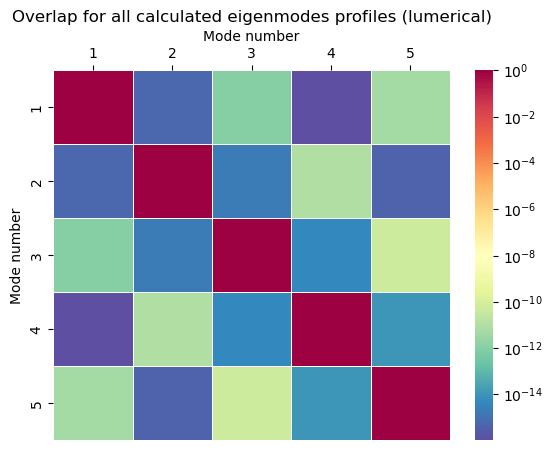

,1,2,3,4,5
1,1.000000e+00,5.865947e-16,1.028609e-12,1.074638e-16,4.773552e-12
2,5.865947e-16,1.000000e+00,2.040207e-15,9.688077e-12,3.995483e-16
3,1.028609e-12,2.040207e-15,1.000000e+00,4.698466e-15,5.391249e-11
4,1.074638e-16,9.688077e-12,4.698466e-15,1.000000e+00,9.612844e-15
5,4.773552e-12,3.995483e-16,5.391249e-11,9.612844e-15,1.000000e+00


In [2]:
keke = cms.rect_WG() #constructing the object with default parameters

NPML_l = [100, 100, 100, 100]

keke.FDE(5, NPML_l)

#Visualization
keke.get_overlap(5, 'lumerical')

ВНИМАНИЕ: Найдено только 3 уникальных TE-мод, а запрошено 4!
Отфильтровано 4 уникальных TE-мод.
Мода 1: n_eff = 2.8780, Conf = 74.9%, TE = 99.9%
Мода 2: n_eff = 2.6634, Conf = 74.7%, TE = 99.9%
Мода 3: n_eff = 2.4832, Conf = 74.2%, TE = 99.9%
Мода 4: n_eff = 2.8780, Conf = 74.9%, TE = 99.9%
[2.8779871 -9.88730370e-12j 2.66335018-1.57577543e-11j
 2.48317193-3.72466870e-11j 2.8779871 -9.88730370e-12j]


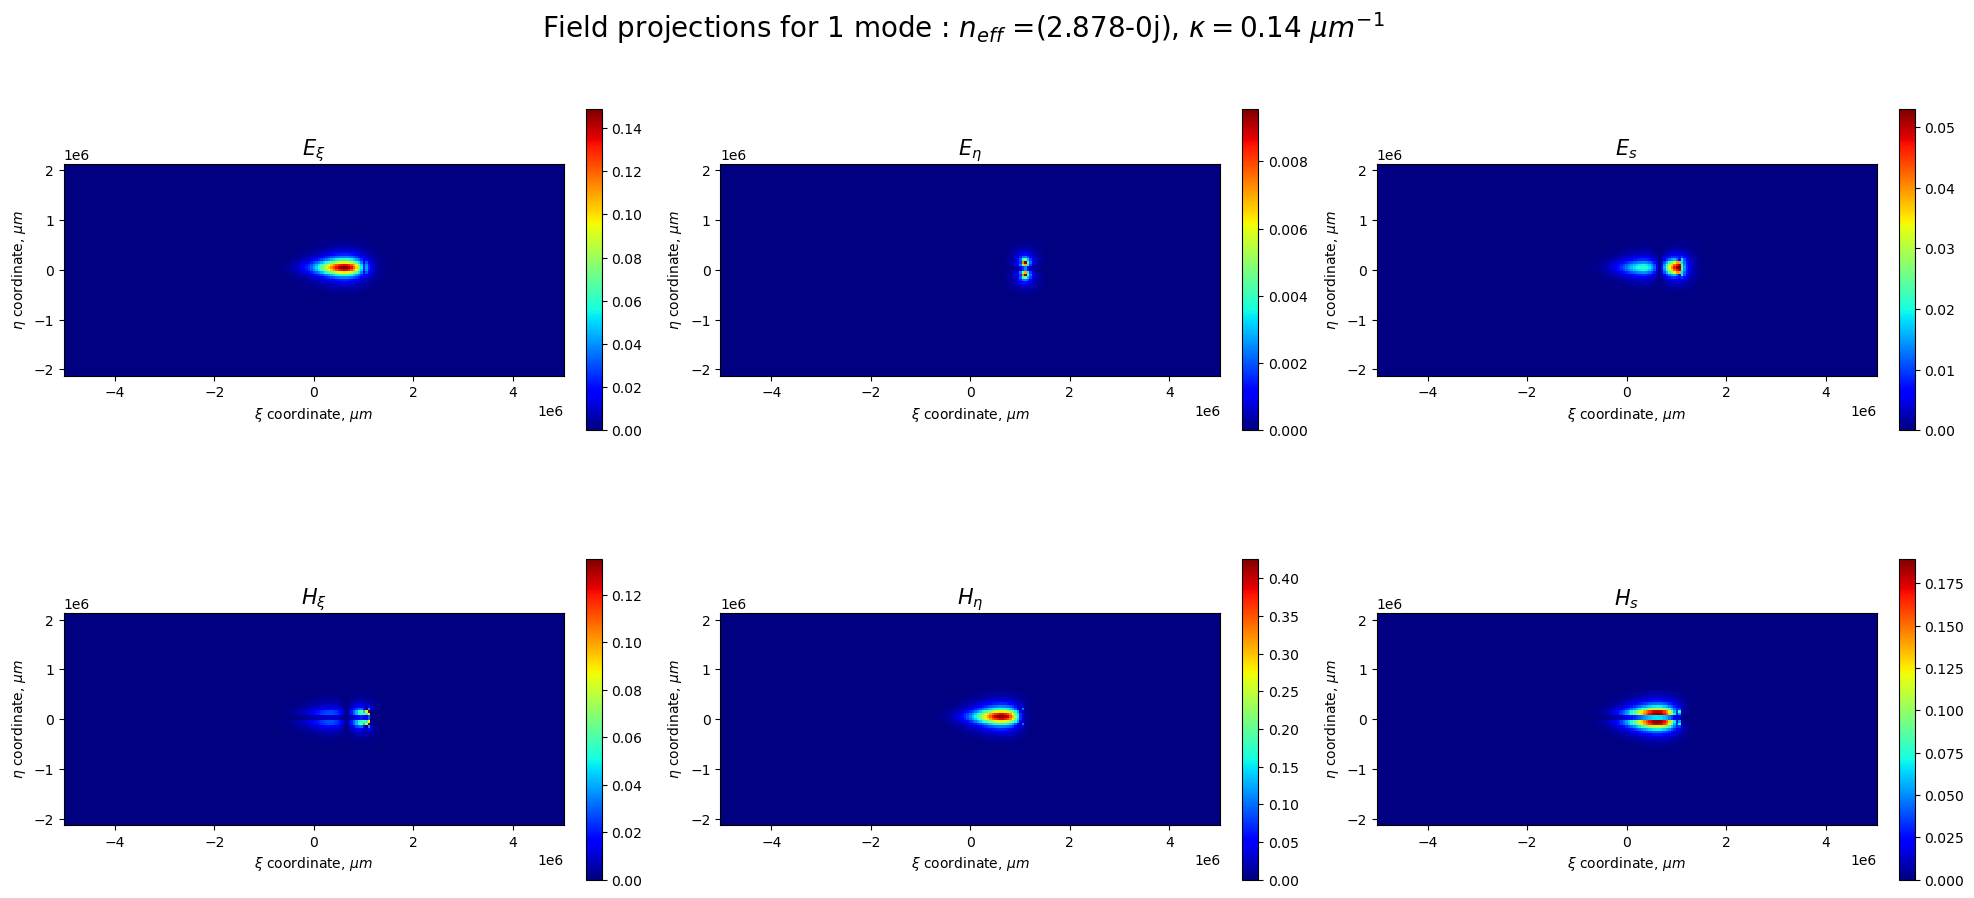

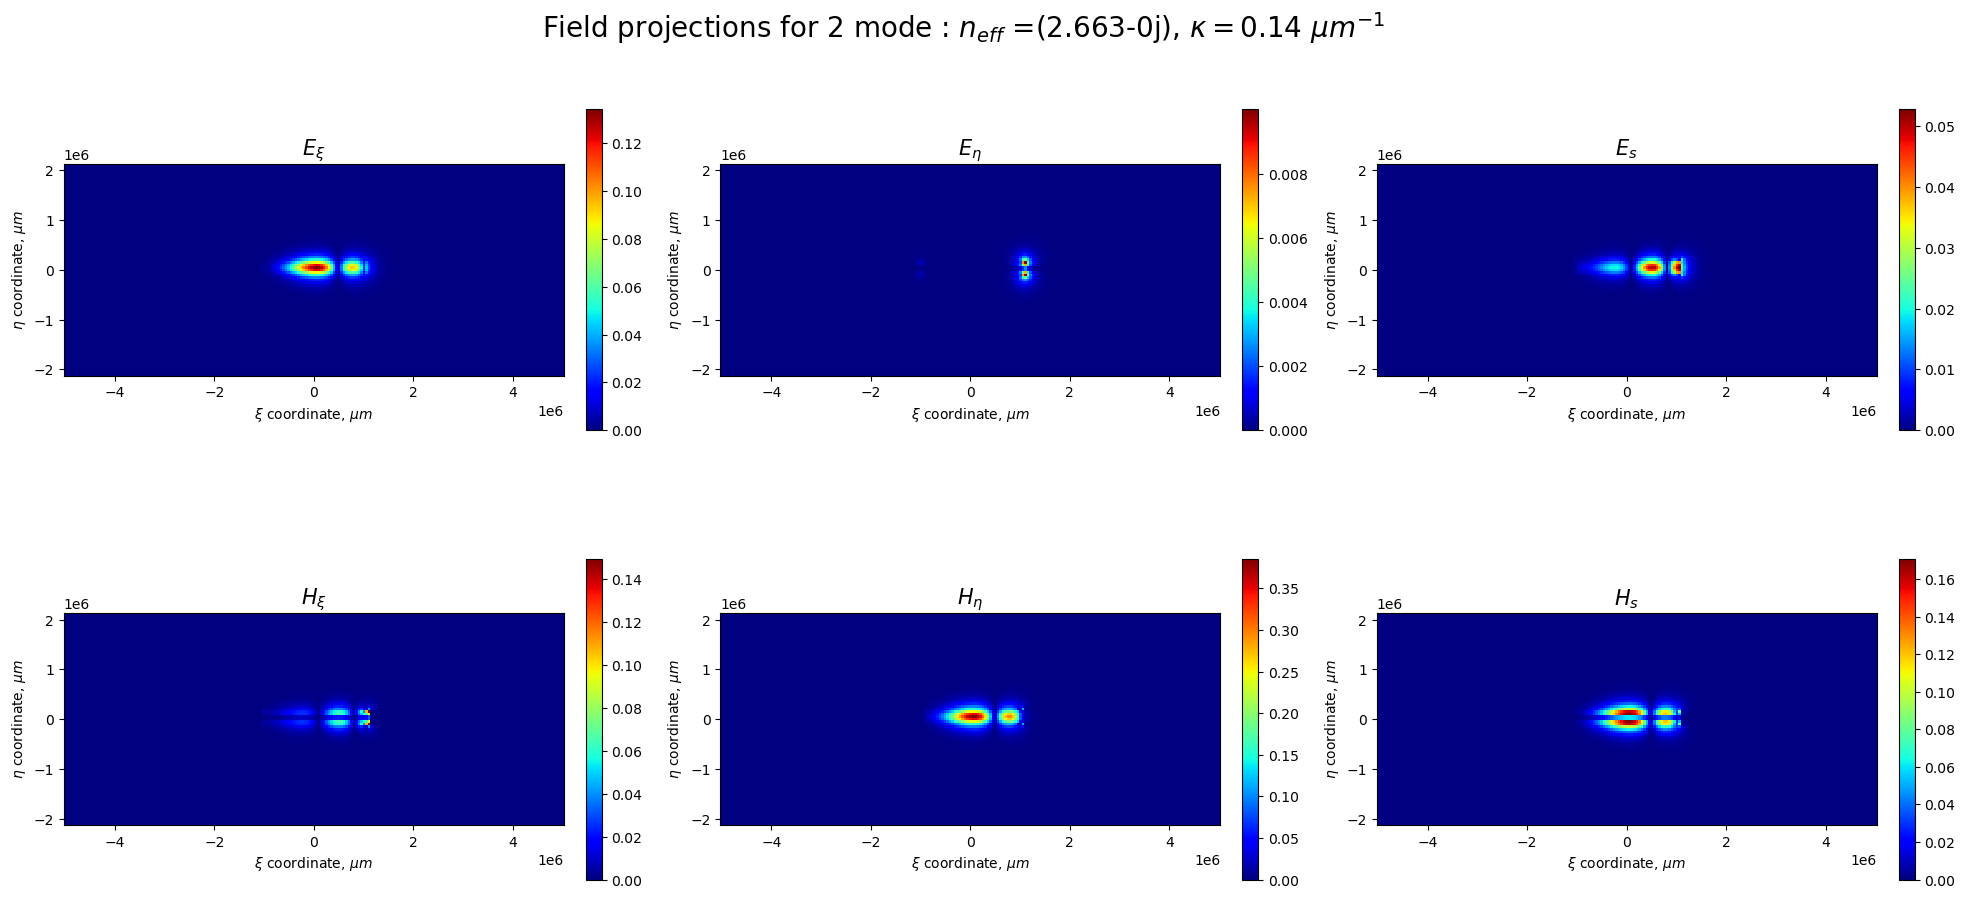

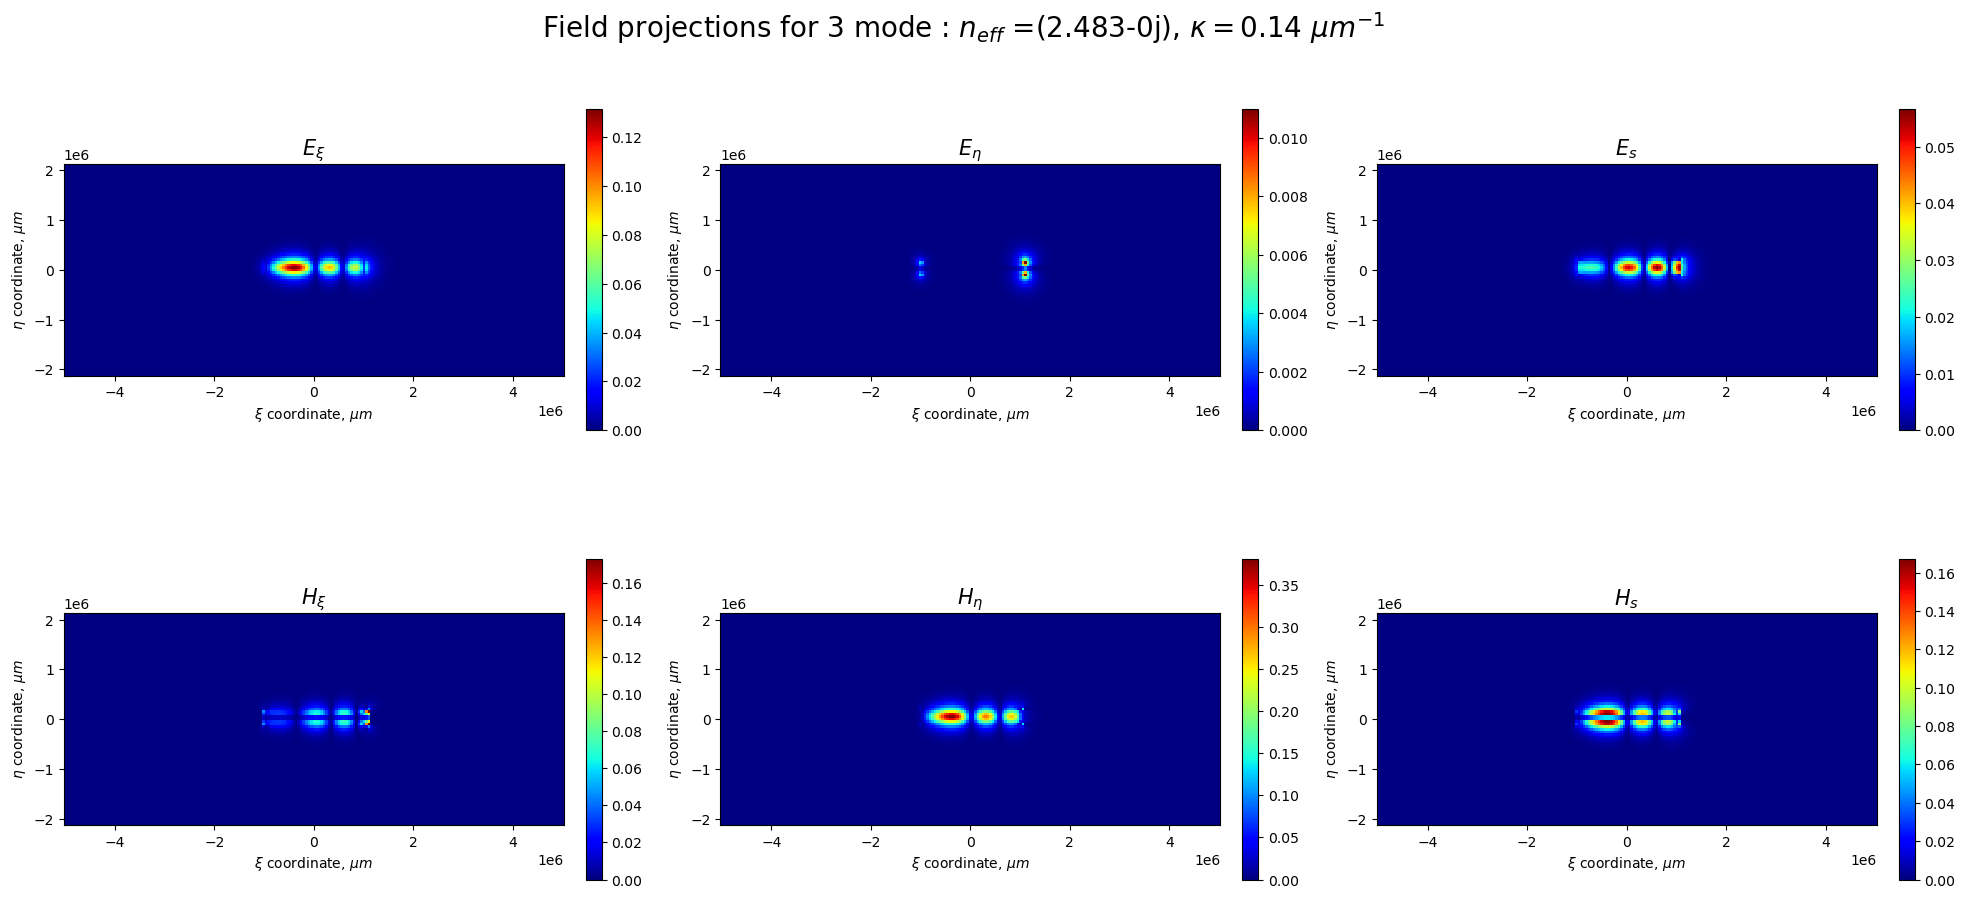

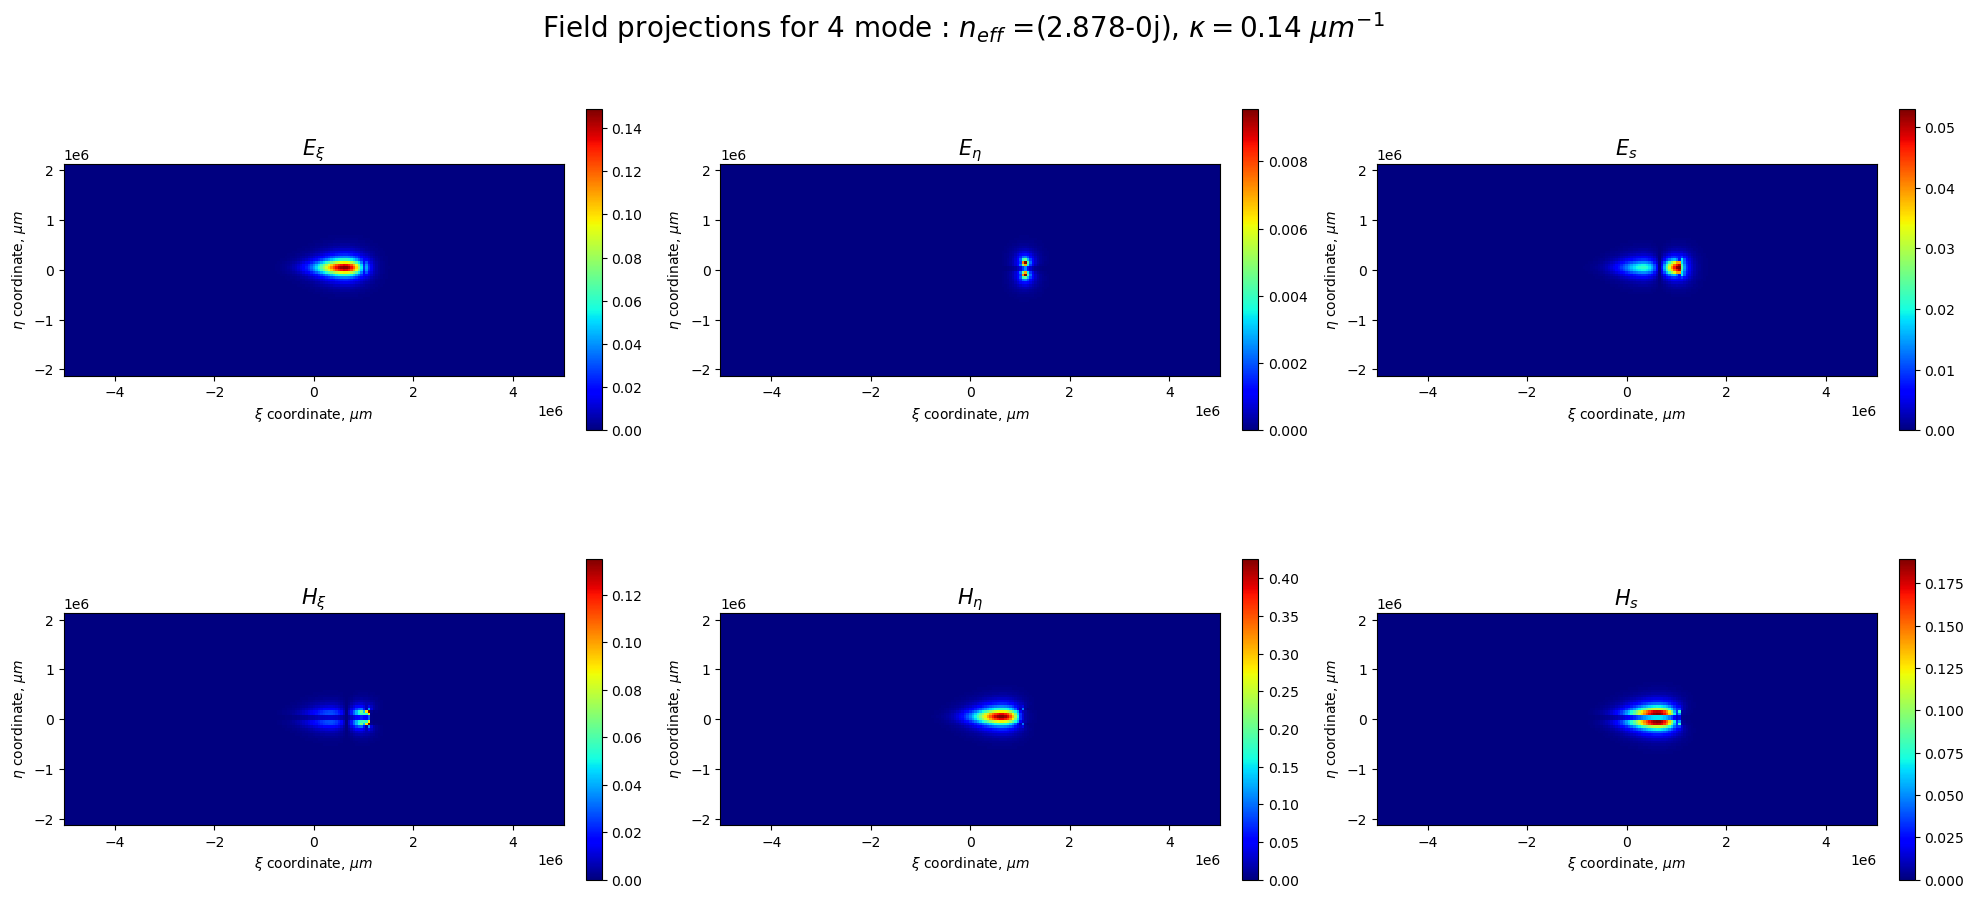

In [6]:
import curved_modesolver as cms

params = {
    'wavelength': 1.55, 'n_clad': 1.444, 'n_core': 3.4755,
    'd_xi': 0.05, 'd_eta': 0.05, 'W': 2, 'H': 0.22, 
    'delta_u': 2.0, 'delta_d': 2.0, 'delta_l': 4.0, 'delta_r': 4.0, 'kappa': 0.13
}

obj = cms.rect_WG(params['wavelength'], params['n_clad'], params['n_core'], params['d_xi'], params['d_eta'], 
                  params['W'], params['H'], params['delta_l'], params['delta_r'], params['delta_u'], params['delta_d'], params['kappa'])

NPML_l = [20, 20, 20, 20]
obj.FDE(4, NPML_l)
print(obj.n_eff)

#Visualization
obj.draw_field(1, 'norm')
obj.draw_field(2, 'norm')
obj.draw_field(3, 'norm')
obj.draw_field(4, 'norm')

# Diff check

In [5]:
import numpy as np
from propagation_solver import ModePropagator

# 1. Упаковываем параметры волновода в словарь (без kappa)
params = {
    'wavelength': 1.55E-6,
    'n_clad': 1.444,
    'n_core': 3.4755,
    'W': 2E-6,
    'H': 0.22E-6,
    'd_xi': 2E-8,
    'd_eta': 2E-8,
    'delta_l': 5E-6,
    'delta_r': 5E-6,
    'delta_u': 3E-6,
    'delta_d': 3E-6
}
NPML_l = [100, 100, 100, 100]

# 2. Инициализируем пропагатор (например, для 2 мод)
propagator = ModePropagator(wg_params=params, num_modes=2, NPML=NPML_l)

# 3. Вычисляем все интегралы для конкретной кривизны (например, \kappa = 0.05)
current_kappa = 0.05
integrals = propagator.compute_integrals(kappa=current_kappa)

print("Матрица I^(1):")
print(integrals['I1'])
print("\nМатрица J^(0):")
print(integrals['J0'])

/Users/User/Desktop/VS code/Curved_modesolver/propagation_solver.py:28: SyntaxWarning: invalid escape sequence '\k'
  """Вспомогательный метод: решает FDE для конкретного \kappa"""


Матрица I^(1):
[[-2.78010679e+05+1.00139437e+04j -1.38828598e-02+2.08868759e-02j]
 [ 5.19706496e-06+6.99189306e-03j  8.09995422e+05+5.82815528e+05j]]

Матрица J^(0):
[[1.02183945e-08-1.79017549e-26j 1.38393469e-08+3.72568926e-07j]
 [1.38393469e-08-3.72568926e-07j 1.07651680e-08-6.41678379e-25j]]
